In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)

In [ ]:
print("CUSTOMER CHURN PREDICTION — RANDOM FOREST CLASSIFIER")

df = pd.read_csv('churn_dataset.csv')

print(f"\nDataset Loaded Successfully")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(f"Churn Rate: {df['churn'].mean()*100:.1f}%")
print(f"\nFirst 5 rows:")
print(df.head().to_string(index=False))

CUSTOMER CHURN PREDICTION — RANDOM FOREST CLASSIFIER

Dataset Loaded Successfully
Rows: 1000  |  Columns: 11
Churn Rate: 52.7%

First 5 rows:
customer_id  tenure  monthly_charges  total_charges  num_services  contract_type  payment_method  tech_support  online_security  senior_citizen  churn
   CUST0001      52           105.57        5381.49             2              1               2             0                0               0      1
   CUST0002      15           103.02        1638.04             5              1               0             1                0               0      1
   CUST0003      61            59.72        3427.29             2              2               0             0                0               0      0
   CUST0004      21            86.81        1843.09             4              0               1             1                1               0      1
   CUST0005      24            40.50        1017.31             3              1               0       

In [ ]:
print("Preprocessing")

# Drop non-feature column
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# Input and Output
print(f"Input Variables  (X): {list(X.columns)}")
print(f"Output Variable  (y): churn  (0 = Retained, 1 = Churned)")

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training Set: {len(X_train)} records")
print(f"Test Set    : {len(X_test)} records")


Preprocessing
Input Variables  (X): ['tenure', 'monthly_charges', 'total_charges', 'num_services', 'contract_type', 'payment_method', 'tech_support', 'online_security', 'senior_citizen']
Output Variable  (y): churn  (0 = Retained, 1 = Churned)
Training Set: 800 records
Test Set    : 200 records


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    random_state=42,    # For reproducibility
    criterion='gini'    # Gini impurity for split quality
)
model.fit(X_train, y_train)
print("Model trained successfully!")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of churn

Model trained successfully!


In [ ]:
acc  = accuracy_score(y_test, y_pred) * 100
prec = precision_score(y_test, y_pred) * 100
rec  = recall_score(y_test, y_pred) * 100
f1   = f1_score(y_test, y_pred) * 100
auc  = roc_auc_score(y_test, y_prob) * 100

print(f"Accuracy  : {acc:.2f}%  — Overall correct predictions")
print(f"Precision : {prec:.2f}%  — Of predicted churners, how many actually churned")
print(f"Recall    : {rec:.2f}%  — Of actual churners, how many were caught")
print(f"F1 Score  : {f1:.2f}%  — Balance between Precision and Recall")
print(f"ROC-AUC   : {auc:.2f}%  — Ability to rank churners above non-churners")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"TN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Accuracy  : 63.00%  — Overall correct predictions
Precision : 64.22%  — Of predicted churners, how many actually churned
Recall    : 66.67%  — Of actual churners, how many were caught
F1 Score  : 65.42%  — Balance between Precision and Recall
ROC-AUC   : 69.70%  — Ability to rank churners above non-churners

Confusion Matrix:
TN=56  FP=39
FN=35  TP=70

Classification Report:
              precision    recall  f1-score   support

    Retained       0.62      0.59      0.60        95
     Churned       0.64      0.67      0.65       105

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



In [ ]:
print("Feature Importance Ranking:\n")

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)
for feat, score in feat_imp.items():
    bar = "█" * int(score * 60)
    print(f"    {feat:<20} {score:.4f}  {bar}")

Feature Importance Ranking:

    monthly_charges      0.2298  █████████████
    total_charges        0.2111  ████████████
    tenure               0.1887  ███████████
    contract_type        0.1161  ██████
    num_services         0.0946  █████
    payment_method       0.0707  ████
    tech_support         0.0330  █
    online_security      0.0328  █
    senior_citizen       0.0232  █


Generating Visualisations...


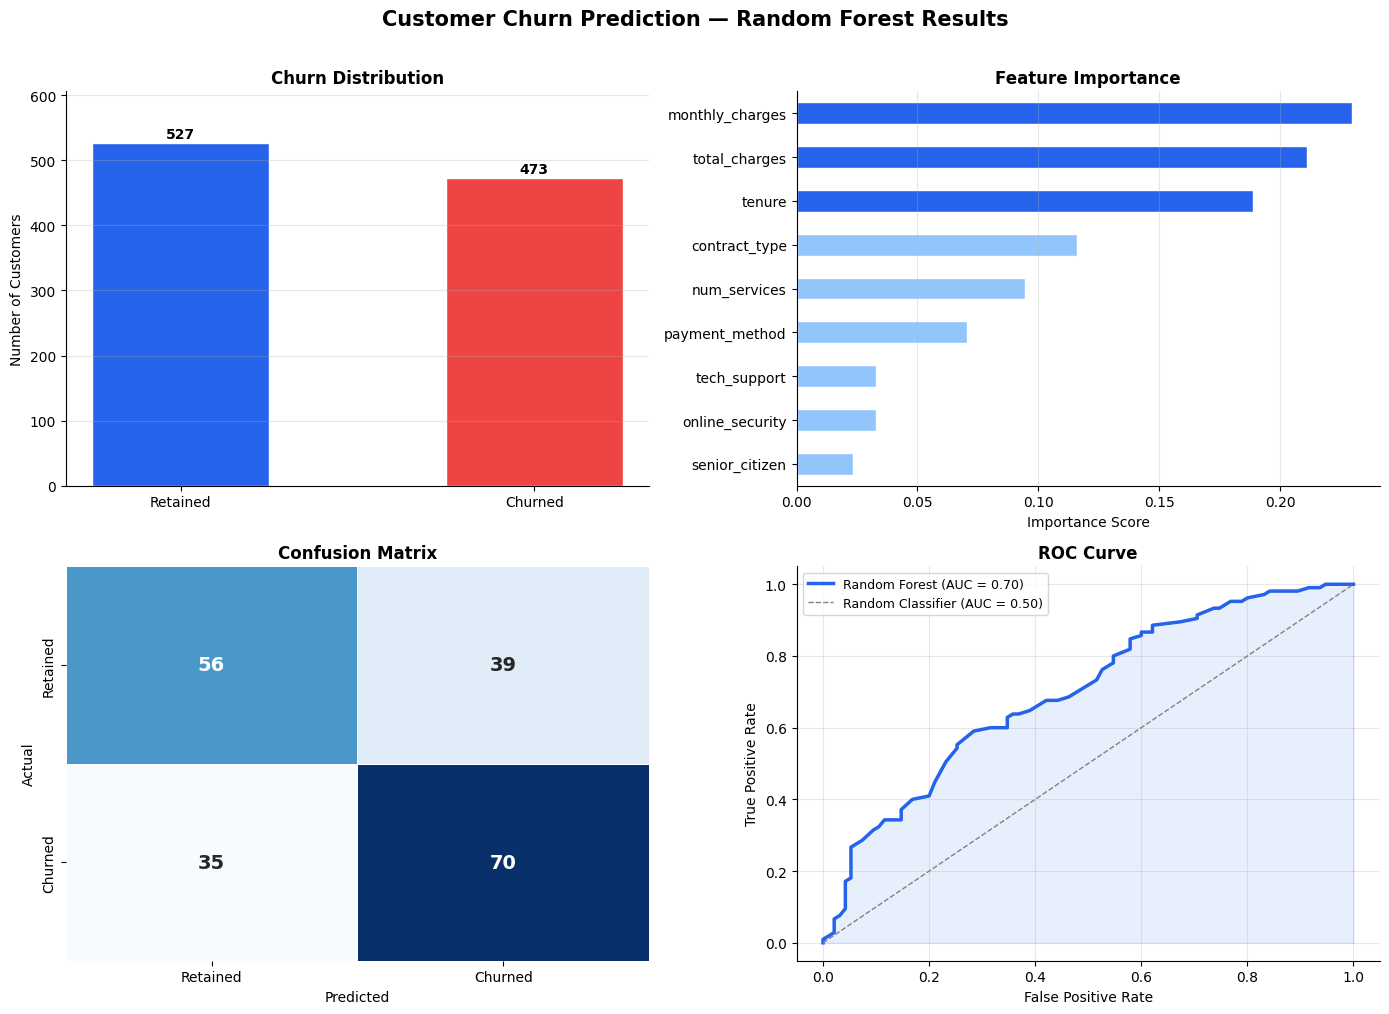

    Charts saved as 'churn_model_results.png'


In [ ]:
print("Generating Visualisations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Prediction — Random Forest Results',
             fontsize=15, fontweight='bold', y=1.01)

BLUE = '#2563EB'; RED = '#EF4444'; GREEN = '#10B981'

# -- Plot 1: Churn Distribution --
ax = axes[0, 0]
counts = df['churn'].value_counts()
bars = ax.bar(['Retained', 'Churned'], counts.values, color=[BLUE, RED],
              edgecolor='white', width=0.5)
ax.set_title('Churn Distribution', fontweight='bold')
ax.set_ylabel('Number of Customers')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            str(val), ha='center', fontweight='bold')
ax.set_ylim(0, max(counts.values)*1.15)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# -- Plot 2: Feature Importance --
ax = axes[0, 1]
colors_bar = [BLUE if v >= feat_imp.nlargest(3).min() else '#93C5FD' for v in feat_imp.values]
feat_imp.sort_values().plot(kind='barh', ax=ax, color=colors_bar[::-1], edgecolor='white')
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

# -- Plot 3: Confusion Matrix --
ax = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=0.5, cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

# -- Plot 4: ROC Curve --
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color=BLUE, lw=2.5, label=f'Random Forest (AUC = {auc/100:.2f})')
ax.fill_between(fpr, tpr, alpha=0.1, color=BLUE)
ax.plot([0,1],[0,1], '--', color='gray', lw=1, label='Random Classifier (AUC = 0.50)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('churn_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Charts saved as 'churn_model_results.png'")

In [ ]:
print("Predict Churn for a New Customer:")

new_customer = pd.DataFrame([{
    'tenure': 5,              # New customer (5 months)
    'monthly_charges': 95.0,  # High monthly charge
    'total_charges': 490.0,
    'num_services': 2,
    'contract_type': 0,       # Month-to-month (highest risk)
    'payment_method': 1,
    'tech_support': 0,        # No tech support
    'online_security': 0,     # No online security
    'senior_citizen': 0
}])

churn_probability = model.predict_proba(new_customer)[0][1]
prediction = model.predict(new_customer)[0]

print(f"Customer Profile  : Low tenure, high charges, month-to-month contract")
print(f"Churn Probability : {churn_probability*100:.2f}%")
print(f"Prediction        : {'LIKELY TO CHURN' if prediction == 1 else 'LIKELY TO STAY'}")
print("\nModel script completed successfully")


Predict Churn for a New Customer:
Customer Profile  : Low tenure, high charges, month-to-month contract
Churn Probability : 87.00%
Prediction        : LIKELY TO CHURN

Model script completed successfully
